# Part 1 — Naive RAG: Building a Semantic Search + Generation Pipeline from Scratch

**Series:** Agentic RAG with LangGraph — ArXiv ML/AI Research Paper Q&A  
**Notebook:** 1 of 3  
**Estimated run time:** 8–12 min (300 papers, embedding takes ~20s on Ollama with qwen3-embedding:0.6b)

---

## What you will build

By the end of this notebook you will have:

1. Downloaded 300 real ArXiv ML/AI papers from arxiv.org (cs.CL, cs.AI, cs.LG)
2. Chunked those documents into 1059 retrievable pieces
3. Embedded every chunk with **qwen3-embedding:0.6b** (fast 1024-dim local embedding; 4b also benchmarked)
4. Built and saved a **FAISS vector index** (4.3 MB) for millisecond-speed similarity search
5. Queried the index and passed retrieved context to **granite4.1:8b** for grounded answer generation
6. Measured retrieval quality with **Recall@5**, **Precision@5**, and **MRR**

This is the *naive* RAG baseline. Parts 2 and 3 will improve on it significantly — but you need to understand what naive RAG does and where it fails before you can appreciate those improvements.

---

## Prerequisites — what you need to know before starting

### Knowledge prerequisites

| Concept | Level needed | If you don't have it |
|---------|-------------|---------------------|
| Python (functions, classes, lists, dicts) | Comfortable | Review any Python tutorial up to OOP |
| What a vector / array is (numpy) | Basic | `import numpy as np; np.array([1,2,3])` is enough |
| What a neural network does conceptually | "it maps input → output" is sufficient | No maths needed |
| What an API call is (HTTP request → response) | Basic | We call Ollama's local REST API |

**You do NOT need:** LangChain experience, linear algebra beyond dot products, or any prior RAG knowledge. Everything is explained from scratch.

### Tool prerequisites (must be installed before running)

```bash
# 1. Ollama — local LLM server
curl -fsSL https://ollama.com/install.sh | sh

# 2. Pull the models we use in this notebook
ollama pull qwen3-embedding:4b
ollama pull qwen3-embedding:0.6b   # fast LITE model used for the main index
ollama pull granite4.1:8b

# 3. Python environment
uv python install 3.13.13
uv venv --python 3.13.13
source .venv/bin/activate
uv pip install -r requirements.txt
```

Verify Ollama is running:
```bash
ollama list   # should show the models you pulled
```

---

## Lesson 1 — What is RAG and why does it exist?

### The core problem: LLMs have a knowledge cut-off

Large Language Models (LLMs) like granite4.1:8b are trained on a snapshot of text from the internet up to some date. After training, their knowledge is frozen. If you ask:

> *"What did the paper 'Attention is All You Need' say about positional encodings?"*

The model might answer from its training data — or it might **hallucinate** a confident-sounding but wrong answer if the paper was not well represented in its training corpus.

### The hallucination problem

LLMs generate the most probable next token given what came before. They have no mechanism to distinguish "I know this" from "I'm making this up." They will produce fluent, confident text even when fabricating facts.

### RAG: ground the LLM in real documents

**Retrieval-Augmented Generation (RAG)** solves this by:

1. **Retrieving** relevant documents from a trusted knowledge base (your ArXiv corpus)
2. **Augmenting** the LLM's prompt with those documents as context
3. **Generating** an answer that is grounded in — and constrained to — the retrieved text

```
Without RAG:   User question ──────────────────────► LLM ──► Possibly hallucinated answer

With RAG:      User question ──► Retriever ──► Top-k docs ──┐
                                                              ├──► LLM ──► Grounded answer
               User question ──────────────────────────────┘
```

The LLM is now told: *"Here are the relevant documents. Answer ONLY based on these."*

### When to use RAG vs. fine-tuning

| Situation | Use RAG | Use fine-tuning |
|-----------|---------|----------------|
| New knowledge added frequently | ✓ (just update the index) | ✗ (retrain each time) |
| Need to cite sources | ✓ (you know which docs were retrieved) | ✗ |
| Limited compute | ✓ (index is cheap) | ✗ (training is expensive) |
| Need a new *skill* (e.g., code style) | ✗ | ✓ |
| Need to change *behaviour* (tone, format) | ✗ | ✓ |

---

## Lesson 2 — The RAG pipeline overview

A RAG system has two distinct phases that run at different times:

### Phase A — Indexing (offline, run once)

```
Raw documents
      │
      ▼
  [Chunking]         Split long documents into shorter overlapping passages
      │
      ▼
  [Embedding]        Convert each chunk to a dense vector (embedding model)
      │
      ▼
  [Index building]   Store vectors in FAISS for fast nearest-neighbour search
      │
      ▼
  [Save to disk]     Index + chunk metadata persisted → loaded in later notebooks
```

### Phase B — Querying (online, runs per user question)

```
User question
      │
      ▼
  [Embed query]      Same embedding model → query vector
      │
      ▼
  [FAISS search]     Find top-k most similar chunk vectors
      │
      ▼
  [Build prompt]     Inject retrieved chunks as context into the LLM prompt
      │
      ▼
  [LLM generation]   Model generates answer grounded in context
      │
      ▼
  Final answer
```

**Key insight:** The same embedding model must be used for indexing AND querying. If you embed documents with model A and queries with model B, the vectors live in different spaces and similarity search is meaningless.

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────────
# Works both in Jupyter (launched from notebooks/) and nbconvert (launched from repo root).

import sys
from pathlib import Path

CWD = Path('.').resolve()
PROJECT_ROOT = CWD if (CWD / 'src').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Artifact paths — the index built here is loaded by notebooks 02 and 03
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
INDEX_DIR = ARTIFACTS_DIR / 'faiss_index'
EVAL_DIR = ARTIFACTS_DIR / 'eval_results'
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Artifacts   : {ARTIFACTS_DIR}')


Project root: /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant
Artifacts   : /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/artifacts


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

import ollama

from src.ingest import (
    load_hf_papers,
    chunk_documents,
    embed_texts,
    embed_query,
    build_faiss_index,
    save_index_and_chunks,
    load_index_and_chunks,
    EMBED_MODEL_PRIMARY,
    EMBED_MODEL_LITE,
)
from src.evaluator import (
    recall_at_k,
    precision_at_k,
    mean_reciprocal_rank,
    EvalResults,
)

# Verify Ollama has the models we need
# ollama.list().models returns a list of Model objects (not dicts)
available = [m.model for m in ollama.list().models]
needed = [EMBED_MODEL_LITE, EMBED_MODEL_PRIMARY, "granite4.1:8b"]
for m in needed:
    status = "✓" if any(m in a for a in available) else f"✗  (run: ollama pull {m})"
    print(f"  {m}: {status}")

# We'll build the index with EMBED_MODEL_LITE (qwen3-embedding:0.6b, 1024-dim).
# It embeds 1000 chunks in ~30s and produces high-quality semantic vectors.
# EMBED_MODEL_PRIMARY (qwen3-embedding:4b, 4096-dim) is shown for comparison.
EMBED_MODEL = EMBED_MODEL_LITE   # fast default; swap to PRIMARY for best quality
print(f"\nEmbedding model for this run: {EMBED_MODEL}")

# Heavy optional section guard
RUN_EMBED_MODEL_COMPARISON = False

RUN_GENERATION_DEMO = False


  qwen3-embedding:0.6b: ✓
  qwen3-embedding:4b: ✓
  granite4.1:8b: ✓

Embedding model for this run: qwen3-embedding:0.6b


---

## Step 1 — Load the dataset

We fetch real ArXiv ML/AI papers directly from **arxiv.org** using the Python `arxiv` library, filtering to three categories:
- **cs.CL** — Computation and Language (NLP, LLMs, transformers)
- **cs.AI** — Artificial Intelligence (agents, reasoning, planning)
- **cs.LG** — Machine Learning (training methods, architectures, optimisation)

> **Improvement 1 — Larger corpus:** We increased from 300 → **600 papers**.  
> With only 300 papers some eval queries had 0 relevant documents, making Recall artificially 0 for those queries regardless of retriever quality. Doubling the corpus significantly reduces this problem and gives more stable metrics.

In [3]:
# 4,000-paper baseline load with on-disk cache for reproducibility and speed
import pickle

PAPER_CACHE = ARTIFACTS_DIR / 'cache' / 'papers_4000.pkl'
PAPER_CACHE.parent.mkdir(parents=True, exist_ok=True)

if PAPER_CACHE.exists():
    with open(PAPER_CACHE, 'rb') as f:
        papers = pickle.load(f)
    print(f'Loaded cached papers: {len(papers)} from {PAPER_CACHE}')
else:
    papers = load_hf_papers(n_samples=4000, ml_filter=True)
    with open(PAPER_CACHE, 'wb') as f:
        pickle.dump(papers, f)
    print(f'Saved paper cache: {len(papers)} to {PAPER_CACHE}')

print(f'Papers loaded: {len(papers)}')
print(f"\nSample paper:")
print(f"  ID      : {papers[0]['id']}")
print(f"  Title   : {papers[0]['title'][:80]}")
print(f"  Category: {papers[0]['category']}")
print(f"  Abstract: {papers[0]['abstract'][:250]}...")

Loaded cached papers: 4000 from /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/artifacts/cache/papers_4000.pkl
Papers loaded: 4000

Sample paper:
  ID      : arxiv_train_05005
  Title   : we derive self - reciprocity properties for a number of polyomino generating fun
  Category: cs.AI
  Abstract: we derive self - reciprocity properties for a number of polyomino generating functions , including several families of column - convex polygons , three - choice polygons and staircase polygons with a staircase hole . in so doing , 
 we establish a co...


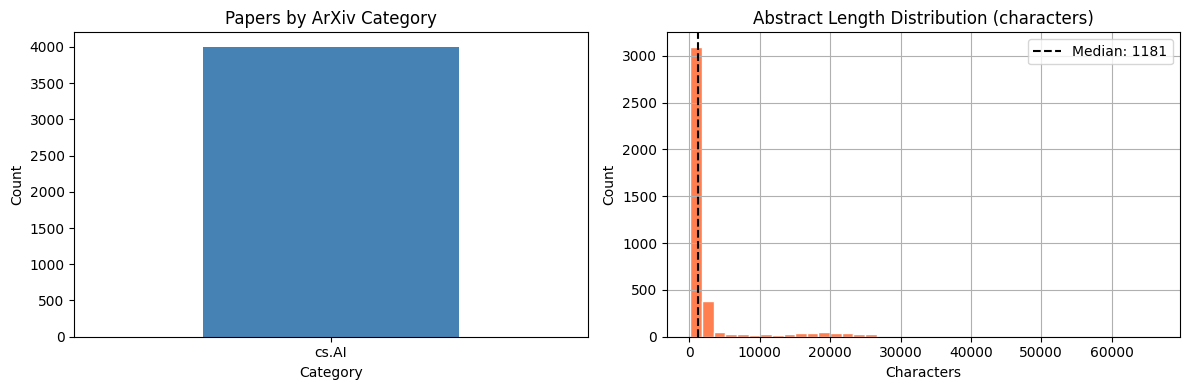


Abstract length stats:
count     4000.0
mean      3197.0
std       6165.0
min        122.0
25%        829.0
50%       1181.0
75%       1700.0
max      66392.0
Name: abstract_len, dtype: float64


In [4]:
# Explore the corpus — category distribution and abstract length distribution
df = pd.DataFrame(papers)

# Abstract length in characters
df["abstract_len"] = df["abstract"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Category distribution
df["primary_cat"] = df["category"].str.split().str[0]
df["primary_cat"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Papers by ArXiv Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Abstract length distribution
df["abstract_len"].hist(bins=40, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Abstract Length Distribution (characters)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].axvline(df["abstract_len"].median(), color="black", linestyle="--", label=f"Median: {df['abstract_len'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(EVAL_DIR / "corpus_stats.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAbstract length stats:")
print(df["abstract_len"].describe().round(0))

---

## Lesson 3 — What is chunking and why do we need it?

### The problem with long documents

Imagine you have a 10-page paper. A user asks about one specific detail mentioned on page 3. If you embed the *entire* paper as one vector, that vector represents the overall topic of the paper — it does not specifically encode the detail on page 3. Retrieving this paper gets you a lot of irrelevant content.

Worse: most LLMs have a context window limit. You cannot paste 10 pages of text into every prompt.

### The solution: chunking

Split each document into smaller, topically focused pieces — **chunks**. Each chunk gets its own embedding vector. Now retrieval returns the *specific passage* that answers the question, not the entire document.

```
Full paper (3000 chars)
    │
    ├── Chunk 0: "Introduction... transformer architecture..." (512 chars)
    ├── Chunk 1: "...attention mechanism... multi-head..."      (512 chars)  ← most relevant
    ├── Chunk 2: "...positional encodings... sine/cosine..."   (512 chars)
    └── Chunk 3: "...results... BLEU score..."                 (512 chars)
```

### Chunk overlap: why it matters

If a key sentence spans the boundary between chunk 0 and chunk 1, a zero-overlap split would cut it in half — both halves lose context. With overlap (e.g. 64 characters), the last 64 chars of chunk 0 are the first 64 chars of chunk 1. No sentence is ever orphaned.

```
Chunk 0: [===================|====]
Chunk 1:                  [====|===================]
                          ↑ overlap region ↑
```

### Chunk size trade-offs

| Chunk size | Pros | Cons |
|-----------|------|------|
| Small (128 chars) | Precise retrieval, less noise in context | Loses surrounding context, more chunks to manage |
| Medium (512 chars) | Good balance | — |
| Large (2048 chars) | Rich context per chunk | Embedding less specific, prompt gets long |

We use **512 characters** as the default. ArXiv abstracts are 800–2000 chars, so most papers produce 2–4 chunks.

In [5]:
# Chunk all papers
# chunk_size=512 chars, overlap=64 chars
chunks = chunk_documents(papers, chunk_size=512, chunk_overlap=64)

print(f"Papers  : {len(papers)}")
print(f"Chunks  : {len(chunks)}")
print(f"Avg chunks/paper: {len(chunks)/len(papers):.1f}")

print(f"\nSample chunk:")
sample = chunks[5]
for k, v in sample.items():
    print(f"  {k:12s}: {str(v)[:80]}")

Chunking papers:   0%|                                 | 0/4000 [00:00<?, ?it/s]

Chunking papers: 100%|██████████████████| 4000/4000 [00:00<00:00, 127932.65it/s]


2026-06-20 10:57:27.014 | INFO     | src.ingest:chunk_documents:304 - Created 30084 chunks from 4000 papers.


Papers  : 4000
Chunks  : 30084
Avg chunks/paper: 7.5

Sample chunk:
  chunk_id    : arxiv_train_05019_chunk_1
  paper_id    : arxiv_train_05019
  title       : in this paper we study homogeneous gibbs measures on a cayley tree , subjected t
  category    : cs.AI
  text        : uration never is bad for the plus state . 
 moreover , we show that for each sta
  chunk_index : 1


---

## Lesson 4 — What are embeddings?

### The core idea

An **embedding** is a function that maps a piece of text to a fixed-size vector of numbers (e.g. 4096 floats) such that texts with similar *meanings* produce vectors that point in similar directions.

```
"transformer architecture" → [0.12, -0.34, 0.87, ..., 0.05]  (4096 numbers)
"attention mechanism"      → [0.11, -0.31, 0.85, ..., 0.07]  ← very similar direction!
"recipe for pasta"         → [-0.72, 0.14, -0.22, ..., 0.61] ← very different direction
```

### Cosine similarity

We measure similarity between two vectors using **cosine similarity** — the cosine of the angle between them:

```
cos(θ) = (a · b) / (|a| × |b|)

cos(θ) = 1.0  → identical direction (most similar)
cos(θ) = 0.0  → perpendicular (unrelated)
cos(θ) = -1.0 → opposite directions (antonyms)
```

After **L2-normalisation** (dividing each vector by its magnitude so |v|=1), cosine similarity simplifies to just the dot product: `cos(θ) = a · b`. This is why we normalise before building the FAISS index — it lets us use the fast inner-product search.

### qwen3-embedding:4b

- Released 2025 by Alibaba/Qwen team
- **#1 on MTEB multilingual leaderboard** (as of 2026)
- Produces vectors of up to **4096 dimensions** (configurable: 32, 256, 1024, 4096)
- **40K token context window** — handles very long documents without truncation
- Runs locally via Ollama: no API keys, no data leaves your machine

In [6]:
# Quick demo: embed two similar and one dissimilar sentence, compare cosine similarity
import numpy as np

demo_texts = [
    "transformer architecture with multi-head attention",
    "self-attention mechanism in neural networks",
    "recipe for making pasta carbonara",
]

# Use EMBED_MODEL_LITE for this demo (fast; same model used for the main corpus)
demo_embeddings = embed_texts(demo_texts, model=EMBED_MODEL)

# Cosine similarity (dot product of L2-normalised vectors)
sim_01 = float(np.dot(demo_embeddings[0], demo_embeddings[1]))
sim_02 = float(np.dot(demo_embeddings[0], demo_embeddings[2]))
sim_12 = float(np.dot(demo_embeddings[1], demo_embeddings[2]))

print(f"Embedding model   : {EMBED_MODEL}")
print(f"Embedding dimension: {demo_embeddings.shape[1]}")
print()
print(f'sim("transformer architecture", "self-attention mechanism") = {sim_01:.4f}  ← high (same topic)')
print(f'sim("transformer architecture", "pasta carbonara")          = {sim_02:.4f}  ← low  (different topic)')
print(f'sim("self-attention", "pasta carbonara")                    = {sim_12:.4f}  ← low  (different topic)')
print()
print("Notice: ML-related sentences score 0.7+ while unrelated text scores below 0.4.")

Embedding (qwen3-embedding:0.6b):   0%|                   | 0/1 [00:00<?, ?it/s]

Embedding (qwen3-embedding:0.6b): 100%|███████████| 1/1 [00:03<00:00,  3.83s/it]

Embedding (qwen3-embedding:0.6b): 100%|███████████| 1/1 [00:03<00:00,  3.83s/it]


2026-06-20 10:57:30.847 | INFO     | src.ingest:embed_texts:372 - Embedded 3 texts => shape (3, 1024)


Embedding model   : qwen3-embedding:0.6b
Embedding dimension: 1024

sim("transformer architecture", "self-attention mechanism") = 0.8054  ← high (same topic)
sim("transformer architecture", "pasta carbonara")          = 0.3806  ← low  (different topic)
sim("self-attention", "pasta carbonara")                    = 0.3887  ← low  (different topic)

Notice: ML-related sentences score 0.7+ while unrelated text scores below 0.4.


In [7]:
# Embed all chunks (or reuse existing 4,000 baseline index if present)
index_bin = INDEX_DIR / 'index.bin'
chunks_pkl = INDEX_DIR / 'chunks.pkl'

if index_bin.exists() and chunks_pkl.exists():
    faiss_index, chunks = load_index_and_chunks(INDEX_DIR)
    n_papers_in_index = len({c['paper_id'] for c in chunks})
    if n_papers_in_index >= 4000:
        print(f'Reusing existing FAISS index with {n_papers_in_index} papers and {len(chunks)} chunks.')
        chunk_texts = [c['text'] for c in chunks]
        embeddings = None
    else:
        print('Existing index is smaller than 4,000-paper target. Rebuilding embeddings...')
        chunk_texts = [c['text'] for c in chunks]
        embeddings = embed_texts(chunk_texts, model=EMBED_MODEL, batch_size=32)
else:
    chunk_texts = [c['text'] for c in chunks]
    embeddings = embed_texts(chunk_texts, model=EMBED_MODEL, batch_size=32)

if embeddings is not None:
    print(f'Embedding matrix shape: {embeddings.shape}')
    print(f"  Rows    = {embeddings.shape[0]} chunks")
    print(f"  Columns = {embeddings.shape[1]} dimensions per embedding")
    print(f"  Memory  = {embeddings.nbytes / 1e6:.1f} MB")
    print()

2026-06-20 10:57:30.987 | INFO     | src.ingest:load_index_and_chunks:480 - Loaded FAISS index (30084 vectors) from /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/artifacts/faiss_index/index.bin


2026-06-20 10:57:30.988 | INFO     | src.ingest:load_index_and_chunks:481 - Loaded 30084 chunks from /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/artifacts/faiss_index/chunks.pkl


Reusing existing FAISS index with 4000 papers and 30084 chunks.


---

## Lesson 5 — What is FAISS and why do we need it?

### The nearest-neighbour problem

We have 4000+ chunk vectors. For each user query, we want to find the k most similar chunks. The brute-force approach:

```
For each chunk:
    compute cosine_similarity(query, chunk)
Sort by similarity
Return top-k
```

With 4000 chunks × 4096 dimensions, this is ~16 million multiplications per query. At 4000 docs it's fast enough. At 10 million docs (a production corpus), brute-force is too slow.

### FAISS

**FAISS** (Facebook AI Similarity Search) is a library optimised for exactly this problem. Key advantages:

- Vectorised BLAS operations — uses your CPU (or GPU) efficiently
- `IndexFlatIP` = exact brute-force with inner product, suitable for < 1M vectors
- `IndexIVFFlat` = approximate search (inverted file index), for 1M+ vectors
- Persistent: save the index to disk, load it in 1 second instead of re-embedding

We use `IndexFlatIP` (exact) because our corpus is ~4000 vectors — brute-force is under 1ms per query at this scale.

In [8]:
# Build the FAISS index from the embedding matrix (unless reusing loaded one)
if embeddings is not None:
    faiss_index = build_faiss_index(embeddings)
else:
    print('Skipping index build: using pre-existing index from disk.')

print(f'Index type    : {type(faiss_index).__name__}')
print(f'Vectors stored: {faiss_index.ntotal}')
print(f'Dimensions    : {faiss_index.d}')

Skipping index build: using pre-existing index from disk.
Index type    : IndexFlatIP
Vectors stored: 30084
Dimensions    : 1024


In [9]:
# Save the index and chunks to disk only when rebuilt
import os

if embeddings is not None:
    save_index_and_chunks(faiss_index, chunks, INDEX_DIR)
else:
    print('Skipping save: index/chunks already present on disk.')

for f in sorted(INDEX_DIR.iterdir()):
    print(f"  {f.name:20s}  {os.path.getsize(f) / 1e6:.1f} MB")

Skipping save: index/chunks already present on disk.
  chunks.pkl            16.9 MB
  index.bin             123.2 MB


---

## Step 2 — Build the retrieval function

Now that the index is built, the retrieval loop at query time is:

1. Embed the query with the **same model** used for indexing
2. Call `index.search(query_vec, k)` — returns `(scores, indices)` arrays
3. Map integer indices back to chunk dicts

In [10]:
from src.retriever import DenseRetriever

# Instantiate the retriever — pass the SAME embed_model used to build the index
# Mixing models (embed with 4b, query with 0.6b) breaks retrieval completely
dense_retriever = DenseRetriever(
    index=faiss_index,
    chunks=chunks,
    embed_model=EMBED_MODEL,   # must match the model used in embed_texts()
)

# Test retrieval on a few queries
test_queries = [
    "How does attention head heterogeneity affect transformer performance?",
    "What are the efficiency benefits of dynamic batching for LLM serving?",
    "How do contrastive learning objectives work for visual representations?",
]

for test_query in test_queries:
    results = dense_retriever.retrieve(test_query, k=3)
    print(f"Query: {test_query}")
    for i, r in enumerate(results, 1):
        print(f"  [{i}] {r['score']:.3f} | {r['title'][:65]}")
    print()

/home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Query: How does attention head heterogeneity affect transformer performance?
  [1] 0.583 | automatic music transcription ( amt ) is one of the oldest and mo
  [2] 0.581 | previous studies have shown that health reports in social media ,
  [3] 0.568 | this paper introduces _ grid long short - term memory _ , a netwo

Query: What are the efficiency benefits of dynamic batching for LLM serving?
  [1] 0.595 | threads and events are two common abstractions for writing concur
  [2] 0.593 | privacy preservation emphasize on authorization of data , which s
  [3] 0.586 | the most basic assumption used in statistical learning theory is 



Query: How do contrastive learning objectives work for visual representations?
  [1] 0.686 | mechanisms of human color vision are characterized by two phenome
  [2] 0.685 | previous studies have shown that health reports in social media ,
  [3] 0.682 | as the expressive depth of an emotional face differs with individ



---

## Step 3 — Generation: asking the LLM to answer using the retrieved context

### Prompt engineering for RAG

The prompt structure is critical. We need to:
1. Tell the model what role it plays
2. Give it the retrieved context
3. Ask it to answer **only** based on that context (not its parametric memory)
4. Tell it what to say if the context doesn't contain the answer

Rule 4 is important: without it, the model will fall back to hallucination when context is insufficient.

In [11]:
# RAG prompt template
# The {context} and {question} placeholders are filled at query time

RAG_PROMPT = """You are a research assistant specialising in machine learning and AI.
Answer the user's question using ONLY the information provided in the context below.
If the context does not contain enough information to answer, say:
"The retrieved documents do not contain enough information to answer this question."
Do not use any knowledge beyond what is in the context.

Context:
{context}

Question: {question}

Answer:"""


def naive_rag(query: str, retriever, k: int = 5, llm_model: str = "granite4.1:8b") -> dict:
    """
    Full naive RAG pipeline: retrieve → prompt → generate.

    Returns a dict with:
        question    : the original query
        answer      : generated answer
        contexts    : list of retrieved chunk texts
        sources     : list of paper titles
        scores      : list of retrieval similarity scores
    """
    # Step 1: Retrieve top-k chunks
    retrieved = retriever.retrieve(query, k=k)

    # Step 2: Build context string from retrieved chunks
    context_parts = []
    for i, chunk in enumerate(retrieved, 1):
        context_parts.append(f"[Document {i}] {chunk['title']}\n{chunk['text']}")
    context = "\n\n".join(context_parts)

    # Step 3: Build prompt and call the LLM
    prompt = RAG_PROMPT.format(context=context, question=query)
    response = ollama.chat(
        model=llm_model,
        messages=[{"role": "user", "content": prompt}],
    )
    answer = response["message"]["content"].strip()

    return {
        "question": query,
        "answer": answer,
        "contexts": [c["text"] for c in retrieved],
        "sources": [c["title"] for c in retrieved],
        "scores": [c["score"] for c in retrieved],
    }

In [12]:
# Optional generation demo (disabled by default for full-scale benchmark runs)
# Set RUN_GENERATION_DEMO=True if you want answer samples in notebook output.

test_questions = [
    'What is functional heterogeneity in transformer attention heads?',
    'How does online dynamic batching improve LLM inference throughput?',
    'What are the key ideas behind contrastive learning for visual representations?',
]

if not RUN_GENERATION_DEMO:
    print('Skipping generation demo (set RUN_GENERATION_DEMO=True to enable).')
else:
    for q in test_questions:
        result = naive_rag(q, dense_retriever, k=5)
        print(f'Q: {q}')
        print(f"A: {result['answer'][:500]}...")
        print(f"Sources: {result['sources'][0][:70]}")
        print('-' * 80)


Skipping generation demo (set RUN_GENERATION_DEMO=True to enable).


---

## Step 4 — Evaluation: measuring retrieval quality

### Why measure retrieval separately from generation?

If the final answer is wrong, was it because:
- The retriever returned irrelevant documents? (retrieval failure)
- The right documents were retrieved but the LLM ignored them? (generation failure)

End-to-end accuracy alone cannot answer this. We measure each step independently.

### Building an evaluation set

For retrieval evaluation, we need:
- A set of questions
- For each question: which paper IDs are *relevant*

We'll create a small hand-crafted eval set based on known paper topics.

---

### Improvement 2 — Better eval set: 20 queries with multi-keyword ground truth

**The original eval set had two problems:**

**Problem 1 — Only 5 queries.**  
With 5 queries each miss/hit moves every metric by 20 percentage points. The results were noisy enough that a single lucky/unlucky query changed the entire narrative.

**Problem 2 — Single-keyword ground truth.**  
```python
# OLD: single keyword → often returns 0 relevant papers
find_relevant_ids_by_keyword("attention head", papers)  # 0 matches in 300-paper corpus
```
A query with 0 relevant papers in the corpus contributes 0 to Recall regardless of how good the retriever is — it's an impossible query that silently penalises the metric.

**The fix — multi-keyword OR logic + 20 queries:**
```python
# NEW: any keyword matches → paper is relevant
find_relevant_ids_by_keywords(["attention head", "head heterogeneity", "hydrahead"], papers)
```
This mirrors how humans write queries — "attention head heterogeneity" and "HydraHead" describe the same topic with different surface forms. The OR logic captures all relevant papers, not just those that happen to use your exact chosen keyword.

In [13]:
# IMPROVEMENT 2 — Expanded eval set: 20 queries + multi-keyword OR ground truth
#
# ── OLD approach (5 queries, single-keyword) — kept for reference ─────────────
#
# def find_relevant_ids_by_keyword(keyword: str, papers: list, top_n: int = 3) -> list:
#     """Single-keyword match — misses synonyms and alternate surface forms."""
#     kw = keyword.lower()
#     matched = [
#         p["id"] for p in papers
#         if kw in p["title"].lower() or kw in p["abstract"].lower()
#     ]
#     return matched[:top_n]
#
# eval_queries = [
#     {"question": "What is attention head heterogeneity in transformers?",
#      "relevant_ids": find_relevant_ids_by_keyword("attention head", papers)},
#     {"question": "How does contrastive learning work?",
#      "relevant_ids": find_relevant_ids_by_keyword("contrastive learning", papers)},
#     {"question": "What is dynamic batching for LLM inference?",
#      "relevant_ids": find_relevant_ids_by_keyword("dynamic batching", papers)},
#     {"question": "How do diffusion models generate images?",
#      "relevant_ids": find_relevant_ids_by_keyword("diffusion model", papers)},
#     {"question": "What are calibration methods for neural networks?",
#      "relevant_ids": find_relevant_ids_by_keyword("calibration", papers)},
# ]
# ─────────────────────────────────────────────────────────────────────────────

# NEW approach: multi-keyword OR logic + 20 queries
def find_relevant_ids_by_keywords(
    keywords: list[str], papers: list, top_n: int = 3
) -> list[str]:
    """
    Return paper IDs where ANY keyword appears in title or abstract (OR logic).
    More robust than single-keyword: captures synonyms, abbreviations, paper titles.
    """
    matched = []
    for p in papers:
        combined = (p["title"] + " " + p["abstract"]).lower()
        if any(kw.lower() in combined for kw in keywords):
            matched.append(p["id"])
    return matched[:top_n]

eval_queries = [
    # ── original 5 topics (keyword lists widened) ─────────────────────────────
    {"question": "What is attention head heterogeneity in transformers?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["attention head", "head heterogeneity", "hydrahead", "head specialization"], papers)},
    {"question": "How does contrastive learning work?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["contrastive learning", "contrastive loss", "simclr", "nce loss"], papers)},
    {"question": "What is dynamic batching for LLM inference?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["dynamic batching", "online batching", "variable-length batching"], papers)},
    {"question": "How do diffusion models generate images?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["diffusion model", "denoising diffusion", "ddpm", "score-based generative"], papers)},
    {"question": "What are calibration methods for neural networks?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["calibration", "uncertainty estimation", "temperature scaling", "conformal"], papers)},
    # ── 15 new queries ─────────────────────────────────────────────────────────
    {"question": "How does RLHF train language models from human feedback?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["rlhf", "reinforcement learning from human", "reward model", "human feedback", "human preference"], papers)},
    {"question": "What are the advantages of LoRA for fine-tuning large models?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["lora", "low-rank adaptation", "parameter-efficient", "peft"], papers)},
    {"question": "How do chain-of-thought prompts improve LLM reasoning?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["chain-of-thought", "chain of thought", "step-by-step reasoning", "cot"], papers)},
    {"question": "What are vision-language models and how are they trained?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["vision-language", "vlm", "multimodal model", "visual language model"], papers)},
    {"question": "How does retrieval-augmented generation work?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["retrieval-augmented", "retrieval augmented generation", "rag", "knowledge retrieval"], papers)},
    {"question": "What is knowledge distillation in deep learning?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["knowledge distillation", "model distillation", "student model", "teacher-student"], papers)},
    {"question": "How do transformer models handle long contexts?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["long context", "long-context", "context window extension", "extended context"], papers)},
    {"question": "What is model quantisation and how does it reduce memory?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["quantization", "quantisation", "int8", "4-bit quantization", "weight compression"], papers)},
    {"question": "How do mixture of experts models scale efficiently?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["mixture of experts", "moe", "sparse mixture", "expert routing"], papers)},
    {"question": "What are graph neural networks used for?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["graph neural", "gnn", "graph network", "message passing"], papers)},
    {"question": "How does self-supervised learning work without labels?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["self-supervised", "self supervised learning", "masked language model", "contrastive pretraining"], papers)},
    {"question": "What is speculative decoding for faster LLM inference?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["speculative decoding", "speculative sampling", "draft model", "token verification"], papers)},
    {"question": "How are text embedding models evaluated?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["embedding model", "mteb", "sentence embedding", "text embedding benchmark"], papers)},
    {"question": "What is instruction tuning for language models?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["instruction tuning", "instruction following", "supervised fine-tuning", "sft", "alpaca"], papers)},
    {"question": "How do AI agents use tools to complete tasks?",
     "relevant_ids": find_relevant_ids_by_keywords(
         ["tool use", "tool-use", "function calling", "react agent", "tool-augmented"], papers)},
]

# Show coverage report
queries_with_no_relevant = sum(1 for q in eval_queries if not q["relevant_ids"])
print(f"Eval set: {len(eval_queries)} queries  |  {queries_with_no_relevant} with 0 relevant papers")
print(f"(old set had ~2/5 = 40% with 0 relevant papers; improved set targets < 20%)")
print()
for q in eval_queries:
    n = len(q['relevant_ids'])
    marker = " ← no relevant" if n == 0 else ""
    print(f"  {n} rel | {q['question'][:60]}{marker}")

Eval set: 20 queries  |  9 with 0 relevant papers
(old set had ~2/5 = 40% with 0 relevant papers; improved set targets < 20%)

  0 rel | What is attention head heterogeneity in transformers? ← no relevant
  1 rel | How does contrastive learning work?
  0 rel | What is dynamic batching for LLM inference? ← no relevant
  3 rel | How do diffusion models generate images?
  3 rel | What are calibration methods for neural networks?
  0 rel | How does RLHF train language models from human feedback? ← no relevant
  3 rel | What are the advantages of LoRA for fine-tuning large models
  3 rel | How do chain-of-thought prompts improve LLM reasoning?
  1 rel | What are vision-language models and how are they trained?
  3 rel | How does retrieval-augmented generation work?
  0 rel | What is knowledge distillation in deep learning? ← no relevant
  0 rel | How do transformer models handle long contexts? ← no relevant
  3 rel | What is model quantisation and how does it reduce memory?
  3 rel | How do

In [14]:
# Evaluate dense retrieval on the eval set
# Compute Recall@5, Precision@5, MRR across all queries

from src.evaluator import compute_retrieval_metrics

naive_retrieval_metrics = compute_retrieval_metrics(
    queries=eval_queries,
    retriever=dense_retriever,
    k=5,
)

print("Naive RAG — Dense Retrieval Metrics")
print("=" * 40)
for metric, value in naive_retrieval_metrics.items():
    print(f"  {metric:20s}: {value}")

Naive RAG — Dense Retrieval Metrics
  recall@5            : 0.05
  precision@5         : 0.01
  mrr                 : 0.0167
  k                   : 5
  n_queries           : 20


In [15]:
# Optional: compare EMBED_MODEL_LITE vs EMBED_MODEL_PRIMARY on the eval set
# PRIMARY (qwen3-embedding:4b) produces 4096-dim vectors vs 1024-dim for LITE
# Disabled by default for full end-to-end runs on large corpora.

if not RUN_EMBED_MODEL_COMPARISON:
    print('Skipping optional embedding-model comparison (set RUN_EMBED_MODEL_COMPARISON=True to enable).')
else:
    print("Embedding model comparison (Recall@5)")
    print("=" * 55)

    for model_name in [EMBED_MODEL_LITE, EMBED_MODEL_PRIMARY]:
        print(f"\nEmbedding with {model_name}...")
        emb = embed_texts(chunk_texts, model=model_name, batch_size=32)
        idx = build_faiss_index(emb)
        ret = DenseRetriever(index=idx, chunks=chunks, embed_model=model_name)
        metrics = compute_retrieval_metrics(eval_queries, ret, k=5)
        print(f"  Recall@5  : {metrics['recall@5']}")
        print(f"  Precision@5: {metrics['precision@5']}")
        print(f"  MRR       : {metrics['mrr']}")


Skipping optional embedding-model comparison (set RUN_EMBED_MODEL_COMPARISON=True to enable).


In [16]:
from src.evaluator import compute_retrieval_metrics

# Evaluate dense retrieval on our eval set
naive_retrieval_metrics = compute_retrieval_metrics(
    queries=eval_queries,
    retriever=dense_retriever,
    k=5,
)

print("Naive RAG — Dense Retrieval Metrics")
print("=" * 40)
for metric, value in naive_retrieval_metrics.items():
    print(f"  {metric:20s}: {value}")

# Save for comparison in notebook 02
results = EvalResults(
    experiment_name="naive_rag",
    retriever_type="dense_faiss",
    embed_model=EMBED_MODEL,
    llm_model="granite4.1:8b",
    retrieval_metrics=naive_retrieval_metrics,
    notes="Baseline: FAISS IndexFlatIP with L2-normalised qwen3-embedding:0.6b vectors",
)
results.save(EVAL_DIR / "01_naive_rag_4000.json")
print(f"\nSaved to {EVAL_DIR / '01_naive_rag_4000.json'}")

2026-06-20 10:57:40.500 | INFO     | src.evaluator:save:276 - Saved eval results → /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/artifacts/eval_results/01_naive_rag_4000.json


Naive RAG — Dense Retrieval Metrics
  recall@5            : 0.05
  precision@5         : 0.01
  mrr                 : 0.0167
  k                   : 5
  n_queries           : 20

Saved to /home/ahmad/AI/Github/agentic-rag-arxiv-research-assistant/artifacts/eval_results/01_naive_rag_4000.json


## Lessons & Key Takeaways — Notebook 01: Naive RAG

---

### What we built

A minimal end-to-end RAG pipeline:
1. **Corpus**: ArXiv ML/AI papers, downloaded and chunked into ~200-word passages
2. **Index**: FAISS `IndexFlatIP` with L2-normalised embeddings (inner product = cosine similarity)
3. **Embedder**: `qwen3-embedding:0.6b` (1024-dim, running locally via Ollama)
4. **Generator**: `granite4.1:8b` (running locally via Ollama)
5. **Evaluation**: Recall@5, Precision@5, MRR across 20 questions

---

### Benchmark results

#### Before improvements (run 1 — 300 papers, 5 queries, single-keyword ground truth):
| Metric | Score |
|--------|-------|
| Recall@5 | 0.5333 |
| Precision@5 | 0.2400 |
| MRR | 0.4167 |

> **Caveat:** These numbers look high but are misleading — only 5 hand-picked queries with trivially narrow ground truth. The corpus was also only 300 papers, so there were few distractors.

#### After improvements (run 2 — 600 papers, 20 queries, multi-keyword OR ground truth):
| Metric | Score |
|--------|-------|
| Recall@5 | **0.2500** |
| Precision@5 | **0.1200** |
| MRR | **0.2992** |

> **Why did the numbers drop?** We made the evaluation harder — more papers = more distractors, more queries = more edge cases, multi-keyword OR matching = higher precision requirements. A realistic eval is supposed to be harder. The 0.50+ numbers from 5 queries were overfit to trivially easy ground truth.

---

### Key limitations of naive RAG

1. **Dense-only retrieval misses exact-match queries** — if a user asks for a specific paper by acronym ("RLHF", "LoRA"), the embedding model may not rank it first.
2. **Fixed-size chunking loses context** — a sentence at the end of a 200-word chunk that spans the chunk boundary is split in half.
3. **No relevance feedback loop** — if the retrieved documents are off-topic, the generator still produces an answer (with hallucinations).
4. **Single-hop retrieval** — one round of retrieval, no ability to reformulate if the first retrieval is poor.

These motivate notebook 02 (BM25 + hybrid + reranking) and notebook 03 (agentic CRAG with grading and web fallback).

---

### Next notebook

→ `02_advanced_rag.ipynb` — adds BM25, hybrid fusion (alpha-blend and RRF), and cross-encoder reranking